In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import seaborn as sns
from wordcloud import WordCloud
import warnings

warnings.filterwarnings('ignore')

# Global style
plt.rcParams.update({
    'figure.dpi'       : 130,
    'font.family'      : 'DejaVu Sans',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.titlesize'   : 14,
    'axes.titleweight' : 'bold',
    'axes.labelsize'   : 11,
})
sns.set_theme(style='whitegrid', palette='muted')

# Custom color palette
PALETTE = ['#2196F3','#FF5722','#4CAF50','#9C27B0','#FF9800','#00BCD4','#E91E63','#607D8B']

print('✅ Setup complete')

✅ Setup complete


In [3]:
df = pd.read_csv('amazon.csv')

# Clean price columns
def clean_price(col):
    return col.astype(str).str.replace('[₹,]', '', regex=True).str.strip().astype(float)

df['discounted_price']    = clean_price(df['discounted_price'])
df['actual_price']        = clean_price(df['actual_price'])
df['discount_percentage'] = df['discount_percentage'].astype(str).str.replace('%','',regex=False).str.strip().astype(float)
df['rating']              = pd.to_numeric(df['rating'], errors='coerce')
df['rating_count']        = pd.to_numeric(df['rating_count'].astype(str).str.replace(',','',regex=False), errors='coerce')

df['main_category'] = df['category'].astype(str).str.split('|').str[0].str.strip()
df.dropna(subset=['rating','discounted_price','actual_price'], inplace=True)
df.drop_duplicates(inplace=True)

# Discount tier label
def disc_tier(x):
    if x < 20:   return '< 20%'
    elif x < 40: return '20–40%'
    elif x < 60: return '40–60%'
    elif x < 80: return '60–80%'
    else:        return '80%+'

df['disc_tier'] = df['discount_percentage'].apply(disc_tier)

print(f'✅ Data ready: {df.shape[0]} products, {df["main_category"].nunique()} categories')

✅ Data ready: 1464 products, 9 categories


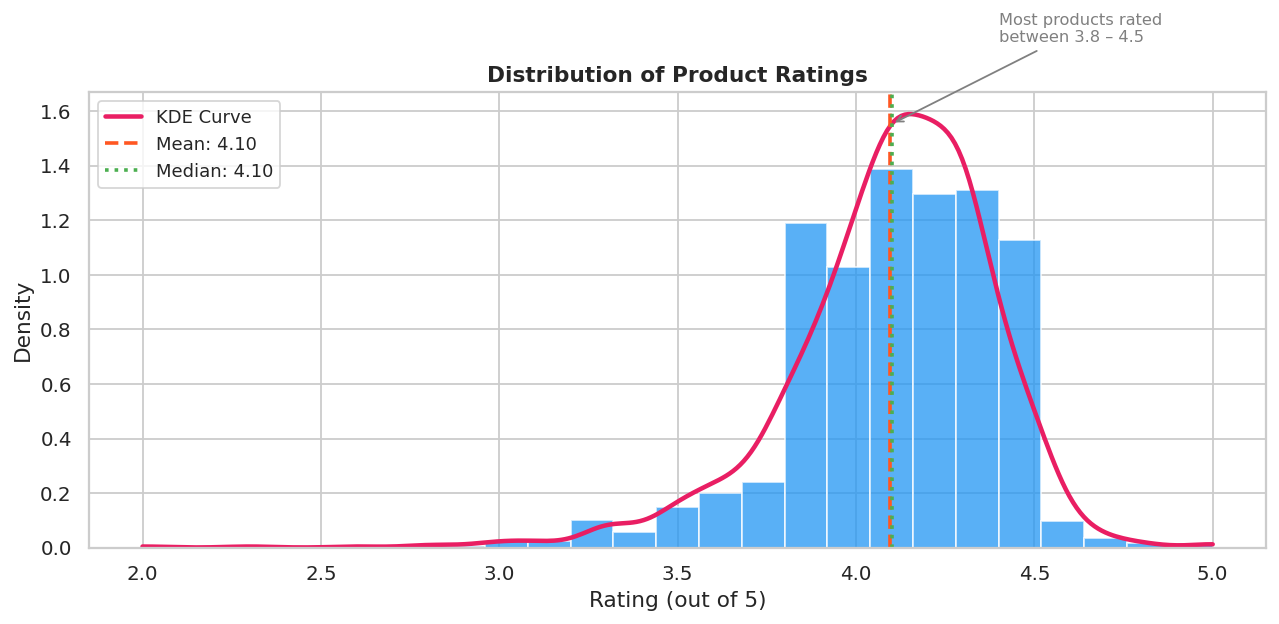

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))

# Histogram
n, bins, patches = ax.hist(df['rating'].dropna(), bins=25,
                            color='#2196F3', edgecolor='white',
                            alpha=0.75, density=True)

# KDE overlay
from scipy.stats import gaussian_kde
kde_x = np.linspace(df['rating'].min(), df['rating'].max(), 300)
kde   = gaussian_kde(df['rating'].dropna())
ax.plot(kde_x, kde(kde_x), color='#E91E63', linewidth=2.5, label='KDE Curve')

# Mean & Median lines
ax.axvline(df['rating'].mean(),   color='#FF5722', linestyle='--', linewidth=2,
           label=f"Mean: {df['rating'].mean():.2f}")
ax.axvline(df['rating'].median(), color='#4CAF50', linestyle=':',  linewidth=2,
           label=f"Median: {df['rating'].median():.2f}")

ax.set_title('Distribution of Product Ratings')
ax.set_xlabel('Rating (out of 5)')
ax.set_ylabel('Density')
ax.legend(fontsize=10)

# Annotation
ax.annotate('Most products rated\nbetween 3.8 – 4.5',
            xy=(4.1, kde(np.array([4.1]))[0]),
            xytext=(4.4, kde(np.array([4.1]))[0] + 0.3),
            arrowprops=dict(arrowstyle='->', color='gray'),
            fontsize=9, color='gray')

plt.tight_layout()
plt.savefig('viz_01_rating_distribution.png', bbox_inches='tight')
plt.show()

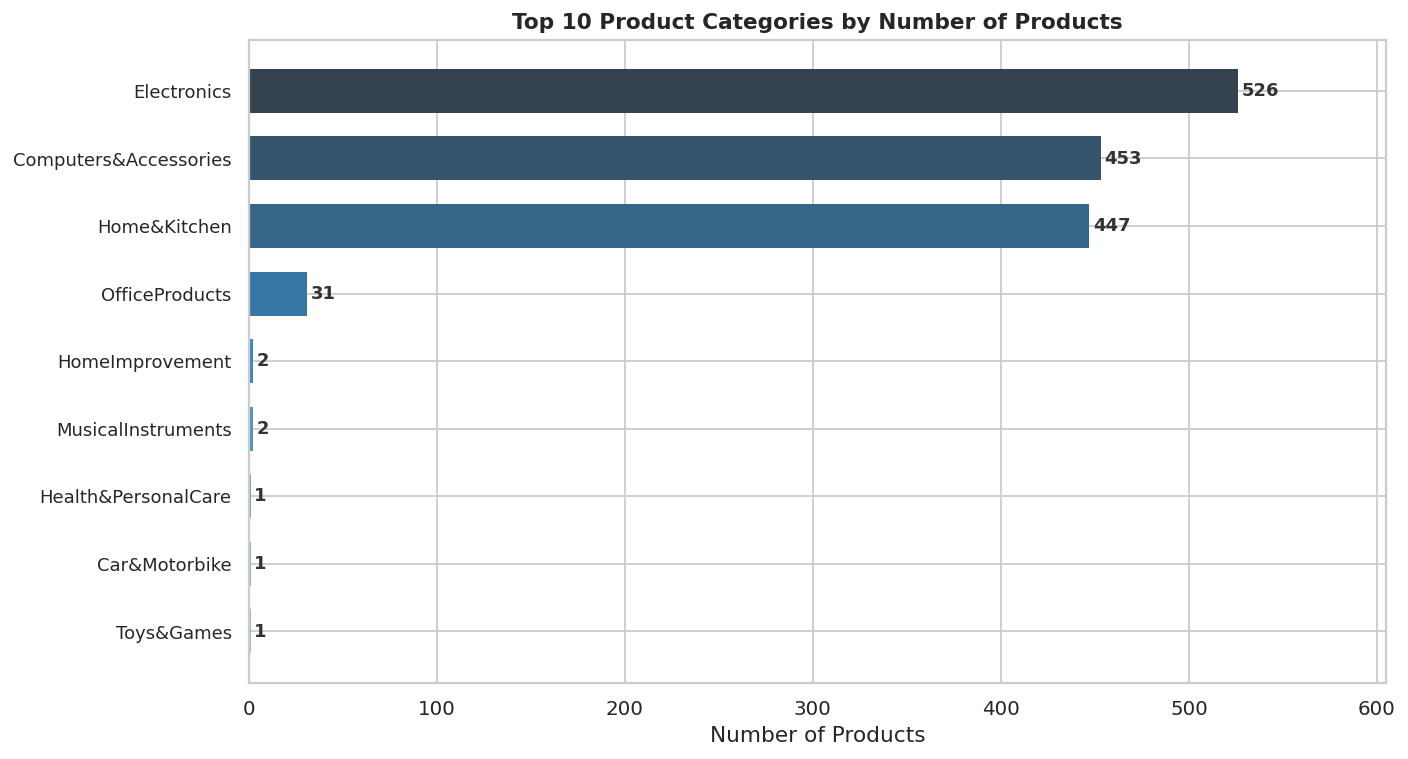

In [5]:
top10 = df['main_category'].value_counts().head(10).sort_values()

fig, ax = plt.subplots(figsize=(11, 6))

colors = sns.color_palette('Blues_d', len(top10))
bars   = ax.barh(top10.index, top10.values, color=colors, edgecolor='none', height=0.65)

for bar, val in zip(bars, top10.values):
    ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
            f'{val}', va='center', fontsize=10, fontweight='bold', color='#333')

ax.set_title('Top 10 Product Categories by Number of Products')
ax.set_xlabel('Number of Products')
ax.set_xlim(0, top10.max() * 1.15)
ax.set_yticklabels(top10.index, fontsize=10)

plt.tight_layout()
plt.savefig('viz_02_top_categories.png', bbox_inches='tight')
plt.show()

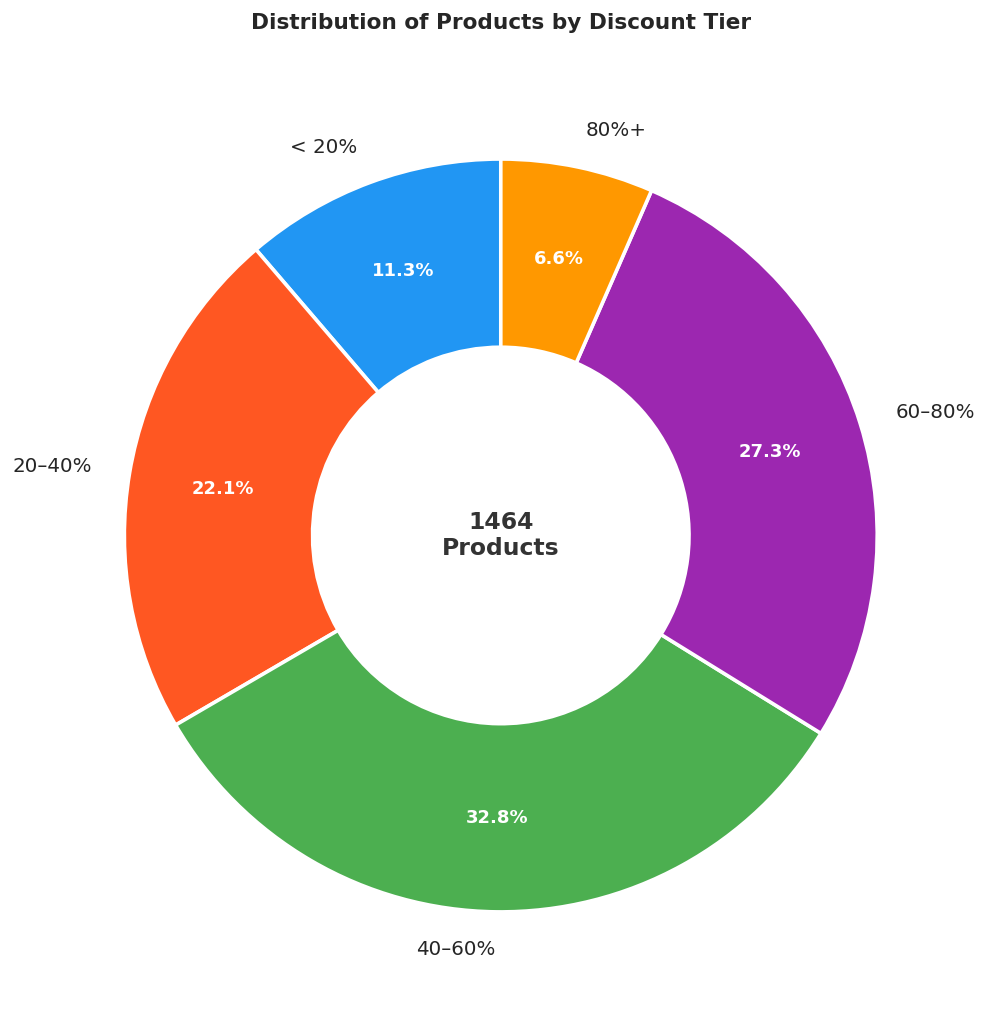

In [6]:
tier_order  = ['< 20%','20–40%','40–60%','60–80%','80%+']
tier_counts = df['disc_tier'].value_counts().reindex(tier_order).dropna()

fig, ax = plt.subplots(figsize=(8, 8))

wedge_props = dict(width=0.5, edgecolor='white', linewidth=2)
wedges, texts, autotexts = ax.pie(
    tier_counts,
    labels=tier_counts.index,
    autopct='%1.1f%%',
    colors=PALETTE[:len(tier_counts)],
    wedgeprops=wedge_props,
    startangle=90,
    pctdistance=0.75
)

for t in autotexts:
    t.set_fontsize(10)
    t.set_fontweight('bold')
    t.set_color('white')

# Center label
ax.text(0, 0, f'{len(df)}\nProducts', ha='center', va='center',
        fontsize=13, fontweight='bold', color='#333')

ax.set_title('Distribution of Products by Discount Tier', pad=20)

plt.tight_layout()
plt.savefig('viz_03_discount_tiers.png', bbox_inches='tight')
plt.show()

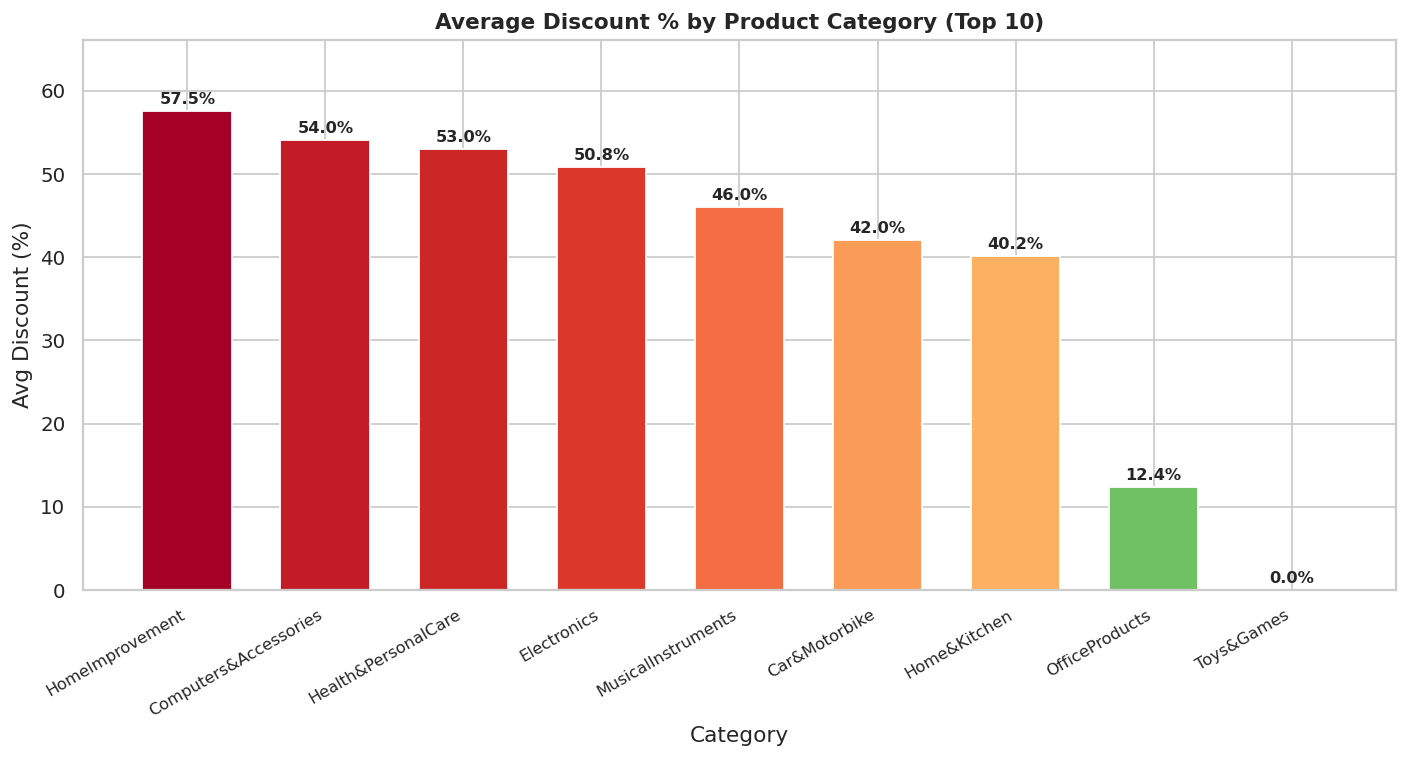

In [7]:
cat_disc = (
    df.groupby('main_category')['discount_percentage']
    .mean().sort_values(ascending=False).head(10)
)

fig, ax = plt.subplots(figsize=(11, 6))

norm_vals = (cat_disc - cat_disc.min()) / (cat_disc.max() - cat_disc.min())
colors    = plt.cm.RdYlGn_r(norm_vals)

bars = ax.bar(cat_disc.index, cat_disc.values, color=colors, edgecolor='white', width=0.65)

for bar, val in zip(bars, cat_disc.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_title('Average Discount % by Product Category (Top 10)')
ax.set_ylabel('Avg Discount (%)')
ax.set_xlabel('Category')
ax.set_xticklabels(cat_disc.index, rotation=30, ha='right', fontsize=9)
ax.set_ylim(0, cat_disc.max() * 1.15)

plt.tight_layout()
plt.savefig('viz_04_discount_by_category.png', bbox_inches='tight')
plt.show()

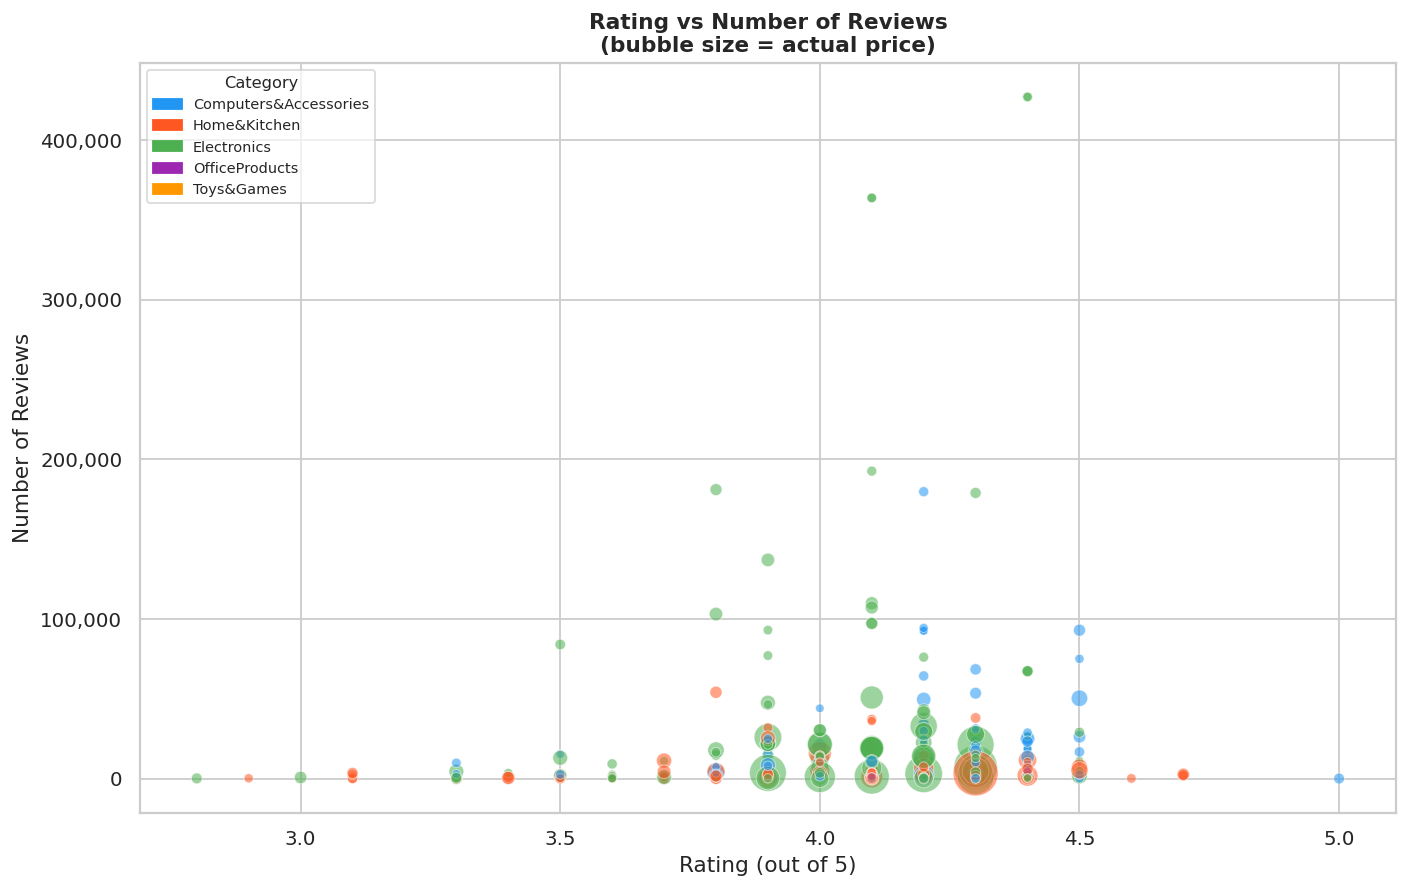

In [8]:
sample = df[['rating','rating_count','actual_price','main_category']].dropna().sample(
    min(400, len(df)), random_state=42
)

# Normalize bubble size
sizes = (sample['actual_price'] / sample['actual_price'].max()) * 600 + 20

# Assign color per category
cats   = sample['main_category'].unique()
c_map  = {c: PALETTE[i % len(PALETTE)] for i, c in enumerate(cats)}
colors = sample['main_category'].map(c_map)

fig, ax = plt.subplots(figsize=(11, 7))

sc = ax.scatter(sample['rating'], sample['rating_count'],
                s=sizes, c=colors, alpha=0.55, edgecolors='white', linewidth=0.5)

ax.set_title('Rating vs Number of Reviews\n(bubble size = actual price)')
ax.set_xlabel('Rating (out of 5)')
ax.set_ylabel('Number of Reviews')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Legend patches
legend_handles = [mpatches.Patch(color=c_map[c], label=c) for c in list(cats)[:6]]
ax.legend(handles=legend_handles, title='Category', fontsize=8,
          title_fontsize=9, loc='upper left', framealpha=0.7)

plt.tight_layout()
plt.savefig('viz_05_bubble_chart.png', bbox_inches='tight')
plt.show()

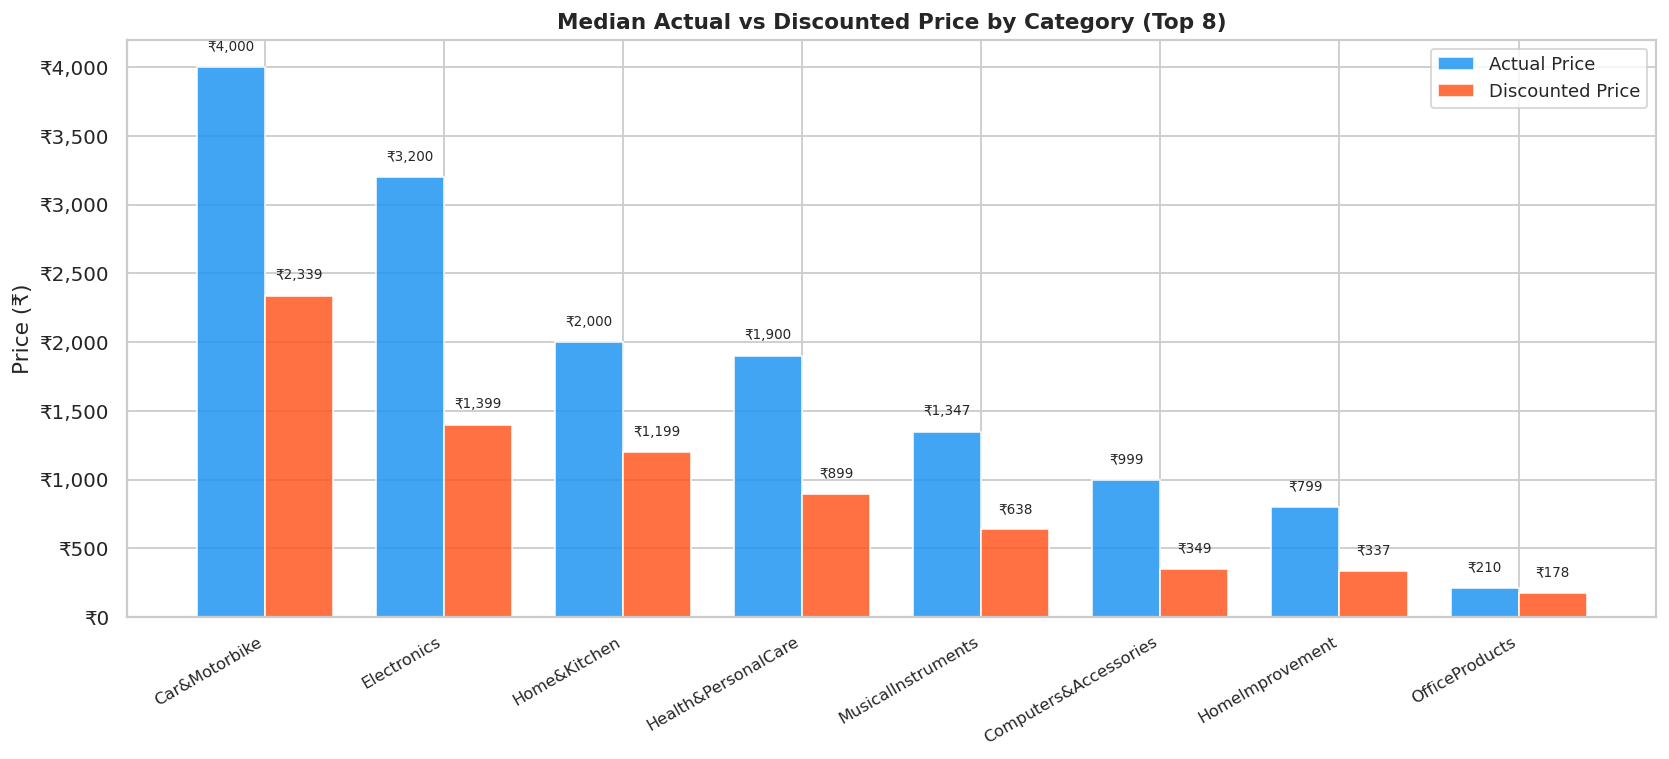

In [9]:
price_comp = (
    df.groupby('main_category')[['actual_price','discounted_price']]
    .median().sort_values('actual_price', ascending=False).head(8)
)

x     = np.arange(len(price_comp))
width = 0.38

fig, ax = plt.subplots(figsize=(13, 6))

b1 = ax.bar(x - width/2, price_comp['actual_price'],     width, label='Actual Price',     color='#2196F3', alpha=0.85)
b2 = ax.bar(x + width/2, price_comp['discounted_price'], width, label='Discounted Price', color='#FF5722', alpha=0.85)

for bar in [*b1, *b2]:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'₹{bar.get_height():,.0f}', ha='center', va='bottom', fontsize=7.5)

ax.set_title('Median Actual vs Discounted Price by Category (Top 8)')
ax.set_ylabel('Price (₹)')
ax.set_xticks(x)
ax.set_xticklabels(price_comp.index, rotation=30, ha='right', fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('viz_06_price_comparison.png', bbox_inches='tight')
plt.show()

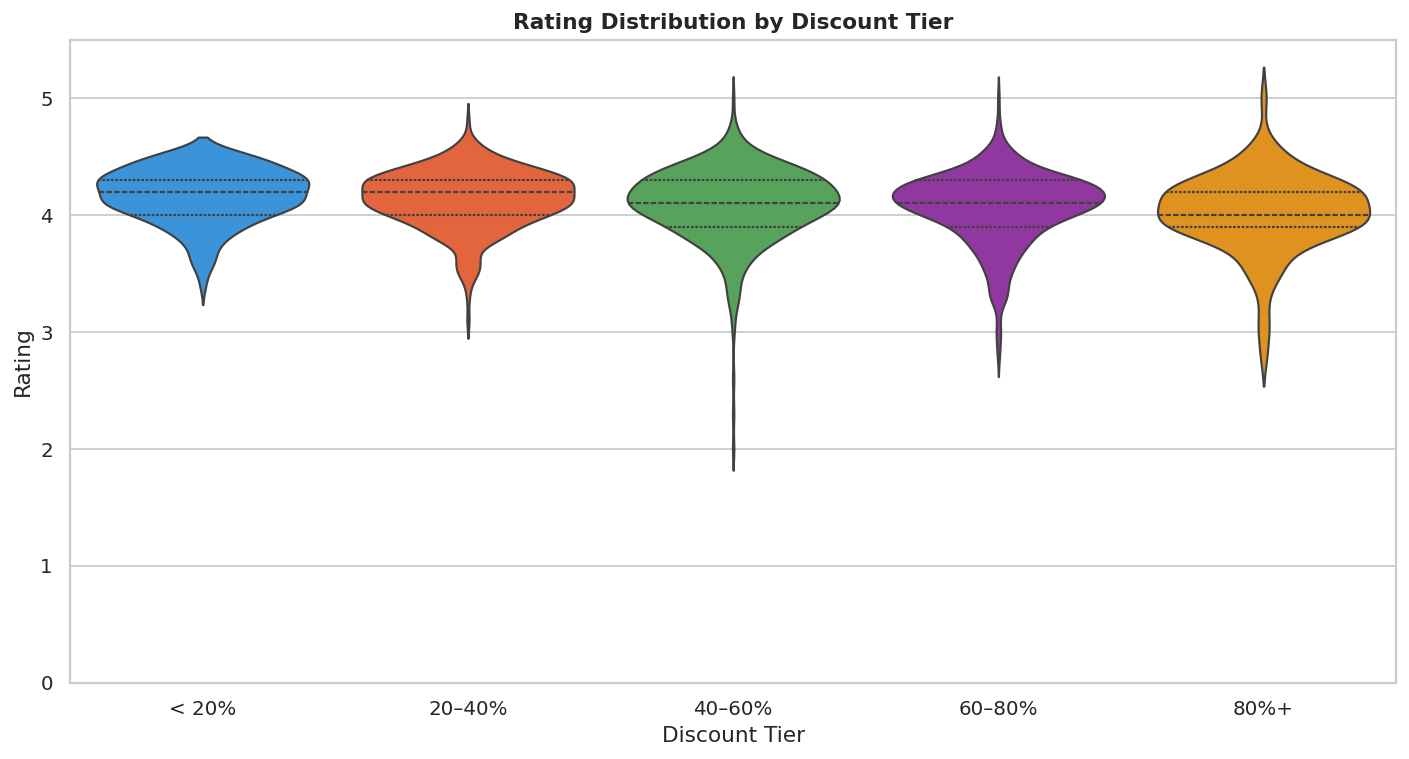

In [10]:
tier_order = ['< 20%','20–40%','40–60%','60–80%','80%+']
plot_df    = df[df['disc_tier'].isin(tier_order)]

fig, ax = plt.subplots(figsize=(11, 6))

sns.violinplot(data=plot_df, x='disc_tier', y='rating',
               order=tier_order, palette=PALETTE[:5],
               inner='quartile', ax=ax, linewidth=1.2)

ax.set_title('Rating Distribution by Discount Tier')
ax.set_xlabel('Discount Tier')
ax.set_ylabel('Rating')
ax.set_ylim(0, 5.5)

plt.tight_layout()
plt.savefig('viz_07_violin_rating_by_tier.png', bbox_inches='tight')
plt.show()

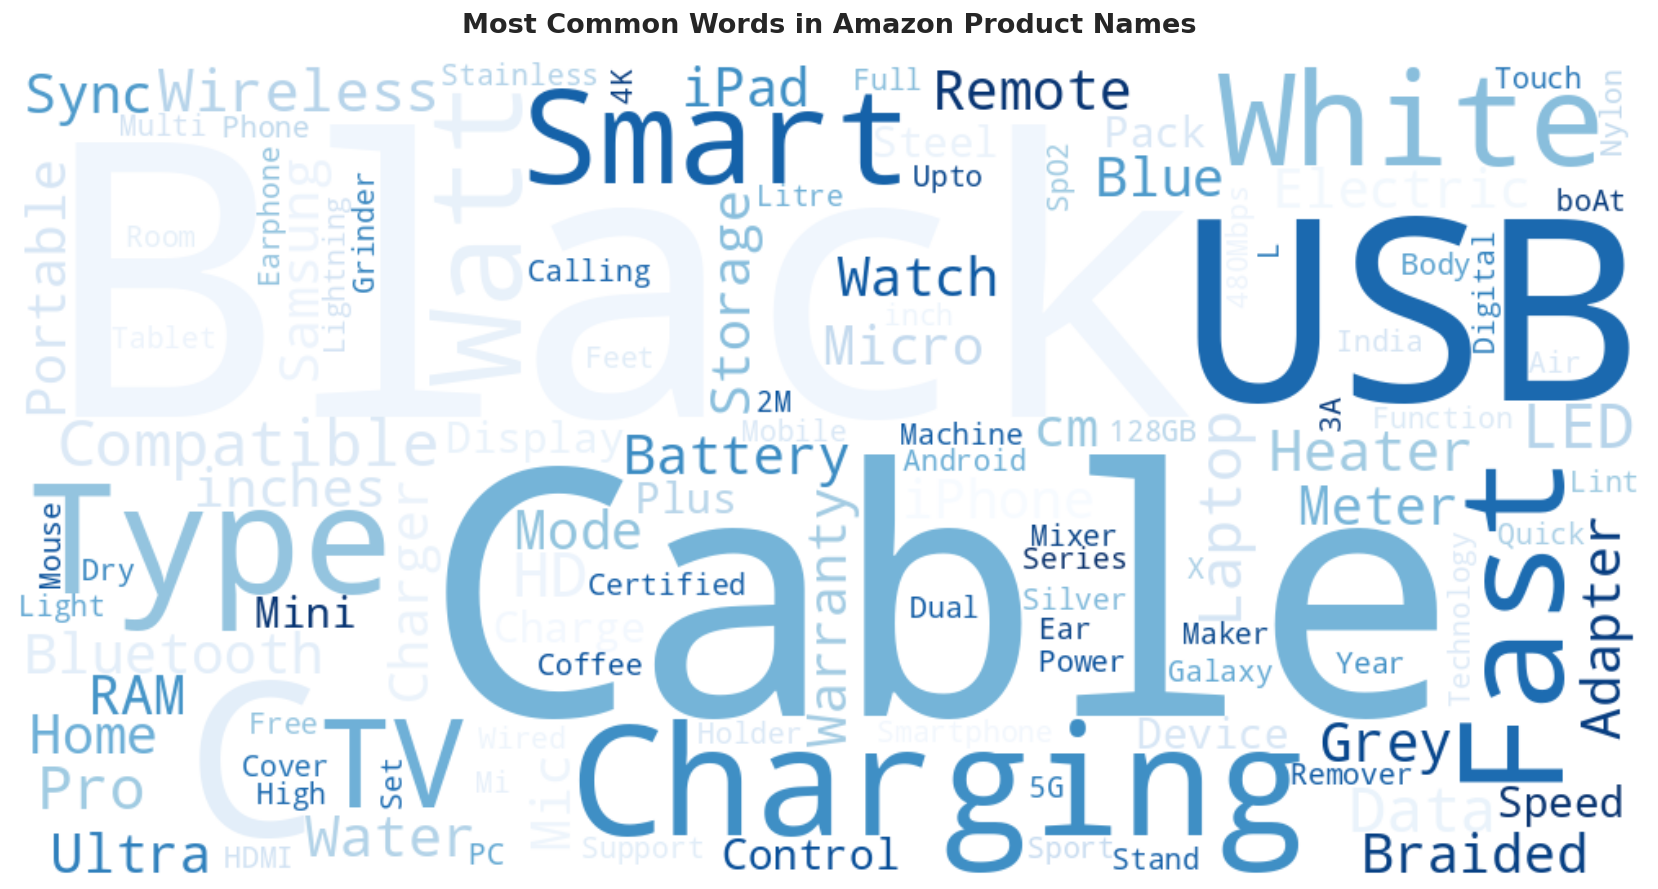

In [11]:
text = ' '.join(df['product_name'].dropna().astype(str).tolist())

wc = WordCloud(
    width=1000, height=500,
    background_color='white',
    colormap='Blues',
    max_words=120,
    collocations=False
).generate(text)

fig, ax = plt.subplots(figsize=(14, 7))
ax.imshow(wc, interpolation='bilinear')
ax.axis('off')
ax.set_title('Most Common Words in Amazon Product Names', fontsize=15, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('viz_08_wordcloud.png', bbox_inches='tight')
plt.show()

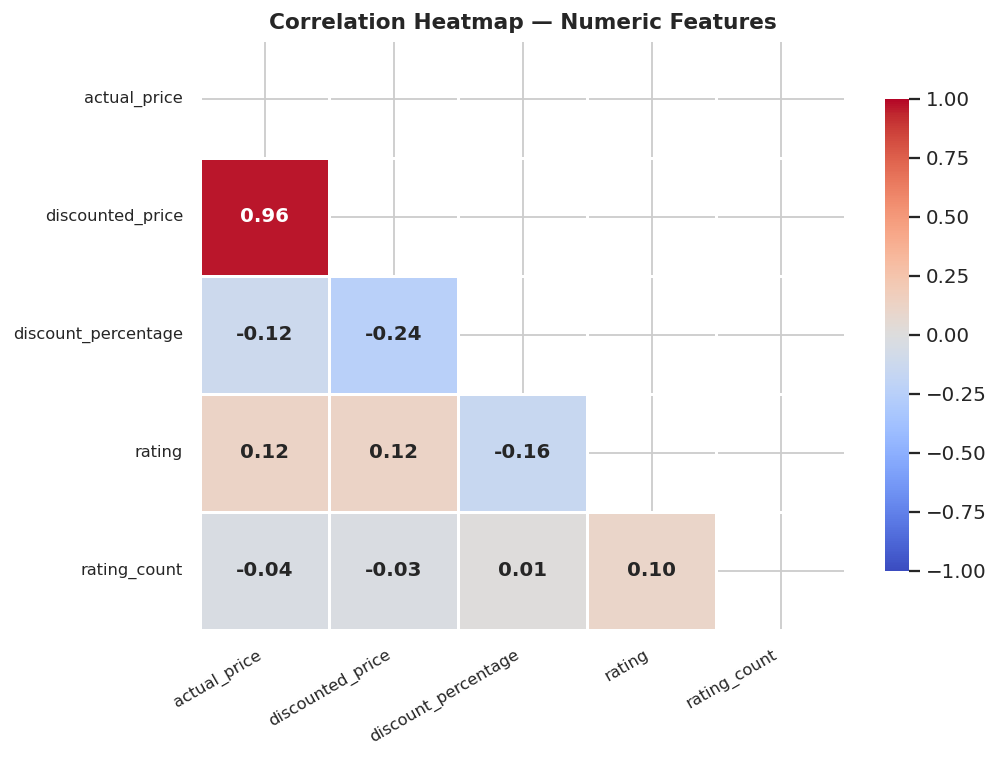

In [12]:
num_cols = ['actual_price','discounted_price','discount_percentage','rating','rating_count']
corr     = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, linewidths=0.8, linecolor='white',
            vmin=-1, vmax=1, ax=ax,
            annot_kws={'size': 11, 'weight': 'bold'},
            cbar_kws={'shrink': 0.8})

ax.set_title('Correlation Heatmap — Numeric Features')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0,  fontsize=9)

plt.tight_layout()
plt.savefig('viz_09_heatmap.png', bbox_inches='tight')
plt.show()

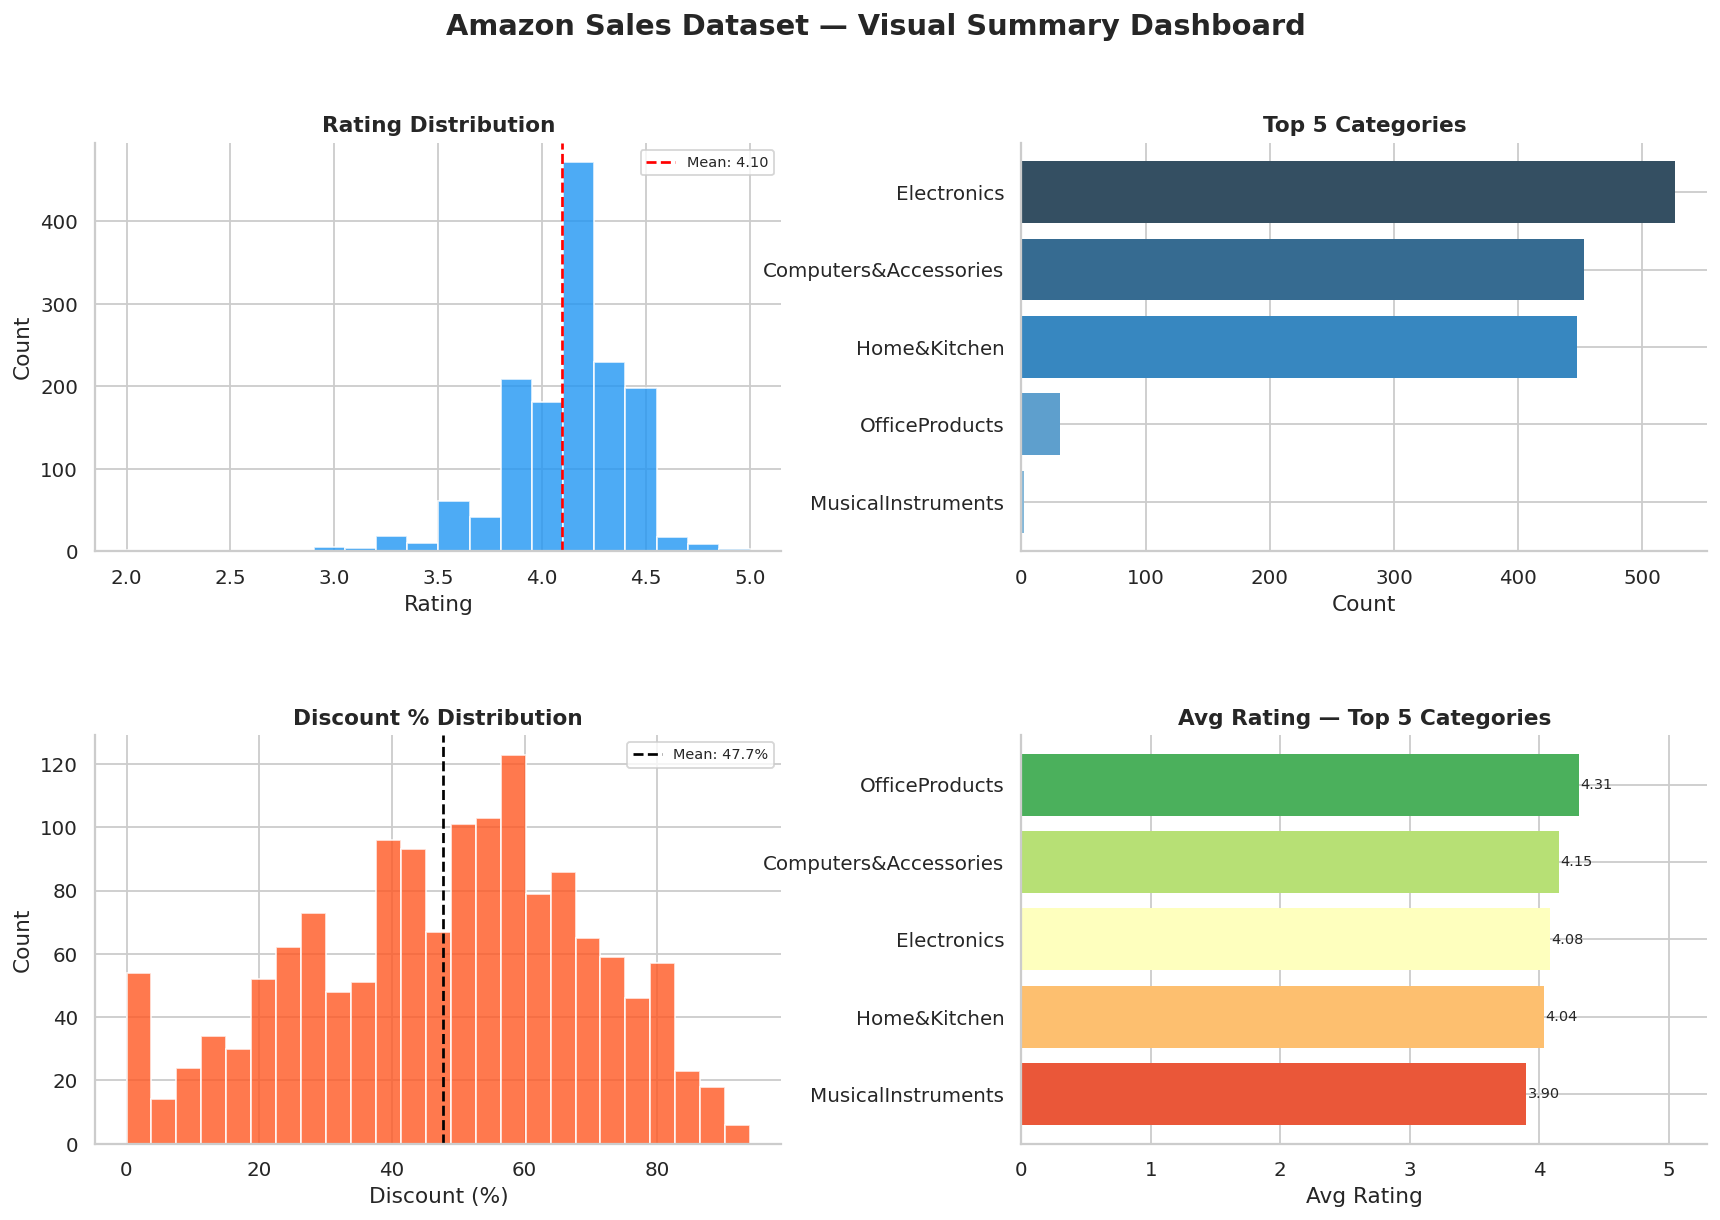

✅ Dashboard saved!


In [13]:
fig = plt.figure(figsize=(16, 10))
fig.suptitle('Amazon Sales Dataset — Visual Summary Dashboard',
             fontsize=16, fontweight='bold', y=0.98)

gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

# --- Panel 1: Rating Histogram ---
ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(df['rating'].dropna(), bins=20, color='#2196F3', edgecolor='white', alpha=0.8)
ax1.axvline(df['rating'].mean(), color='red', linestyle='--',
            label=f"Mean: {df['rating'].mean():.2f}")
ax1.set_title('Rating Distribution')
ax1.set_xlabel('Rating')
ax1.set_ylabel('Count')
ax1.legend(fontsize=8)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# --- Panel 2: Top Categories ---
ax2 = fig.add_subplot(gs[0, 1])
top5 = df['main_category'].value_counts().head(5).sort_values()
ax2.barh(top5.index, top5.values,
         color=sns.color_palette('Blues_d', 5), edgecolor='none')
ax2.set_title('Top 5 Categories')
ax2.set_xlabel('Count')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# --- Panel 3: Discount % Histogram ---
ax3 = fig.add_subplot(gs[1, 0])
ax3.hist(df['discount_percentage'].dropna(), bins=25,
         color='#FF5722', edgecolor='white', alpha=0.8)
ax3.axvline(df['discount_percentage'].mean(), color='black', linestyle='--',
            label=f"Mean: {df['discount_percentage'].mean():.1f}%")
ax3.set_title('Discount % Distribution')
ax3.set_xlabel('Discount (%)')
ax3.set_ylabel('Count')
ax3.legend(fontsize=8)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

# --- Panel 4: Avg Rating by Top 5 Categories ---
ax4 = fig.add_subplot(gs[1, 1])
top5_cats = df['main_category'].value_counts().head(5).index
cat_avg   = df[df['main_category'].isin(top5_cats)].groupby('main_category')['rating'].mean().sort_values()
bars = ax4.barh(cat_avg.index, cat_avg.values,
                color=sns.color_palette('RdYlGn', 5), edgecolor='none')
for bar, val in zip(bars, cat_avg.values):
    ax4.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
             f'{val:.2f}', va='center', fontsize=8)
ax4.set_title('Avg Rating — Top 5 Categories')
ax4.set_xlabel('Avg Rating')
ax4.set_xlim(0, 5.3)
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)

plt.savefig('viz_10_dashboard.png', bbox_inches='tight')
plt.show()
print('✅ Dashboard saved!')